In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
# For manual stuff (added manually)

sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\lagoon_FLAMES\py_modules")
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\lagoon_FLAMES")

from pipeline_config import MAPS_DIR, STRUCTURE_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params


In [3]:
H_ = results_comp.load_line_bundle("FLA-M8-H", "H_line", MAPS_DIR, read_header=True)
N_ = results_comp.load_line_bundle("FLA-M8-N", "N_line", MAPS_DIR, read_header=True)
S_ = results_comp.load_line_bundle("FLA-M8-S", "S_line", MAPS_DIR, read_header=True)


print(H_['obs']['V_mean'].var())
print(N_['obs']['V_mean'].var())
print(S_['obs']['V_mean'].var())


7.526433868794324
10.468659374077292
11.072776813938345


In [4]:
H_['obs']['V_mean'].var()

7.526433868794324

In [5]:
obs = [H_['obs']['V_mean'].var(), N_['obs']['V_mean'].var(), S_['obs']['V_mean'].var()]
obs

[7.526433868794324, 10.468659374077292, 11.072776813938345]

In [6]:
# H
name = 'FLA-M8-H'
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

H_line = ci_results_compiler.ci_results_compiler(fit_Br)

# S
name = 'FLA-M8-S'
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

S_line = ci_results_compiler.ci_results_compiler(fit_Br)

# N
name = 'FLA-M8-N'
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

N_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [7]:
H_line

{'sig2': [7.384741190282623, 1.2420274796048751, 0.7400740977301234],
 'r0': [1.034640471081969, 0.2363952882255307, 0.12229163372446894],
 'm': [1.2639708005668298, 0.17632242566067036, 0.19300681968432976],
 's0': [0.006979430590938273, 0.0018949389090617266, 0.006152852610938273],
 'noise': [0.4366925356421689, 0.20993999331033109, 0.30328855294466894]}

In [8]:
labels  = ['H', 'N', 'S']

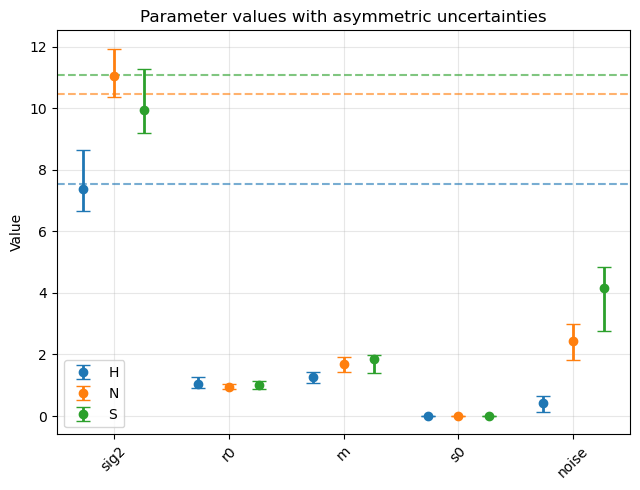

In [9]:

plot_fit_params.plot_param_comp_obs(H_line, N_line, S_line, labels=labels, obs=obs)

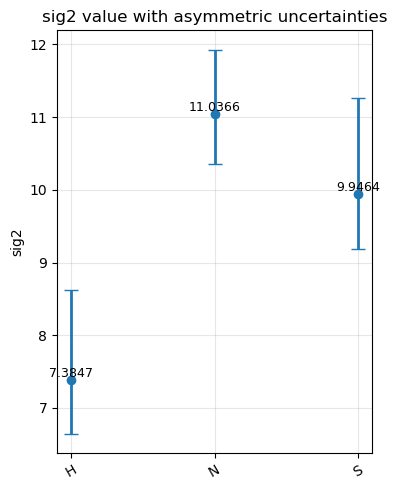

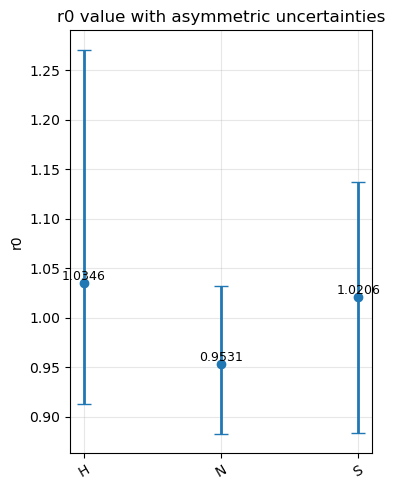

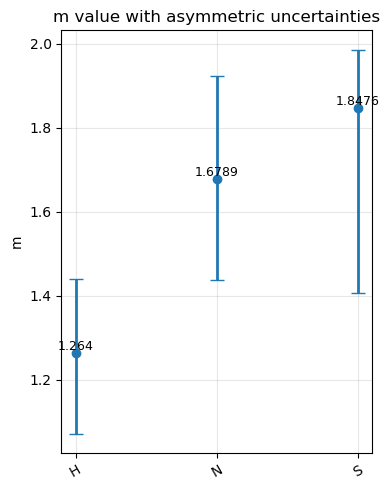

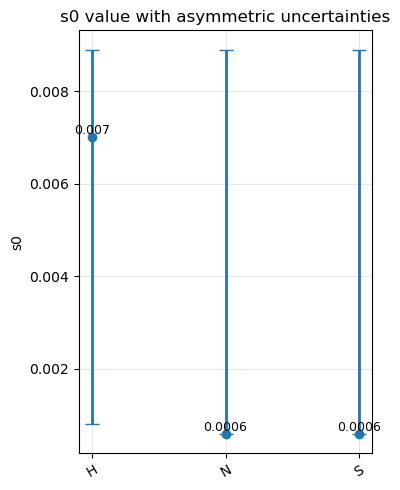

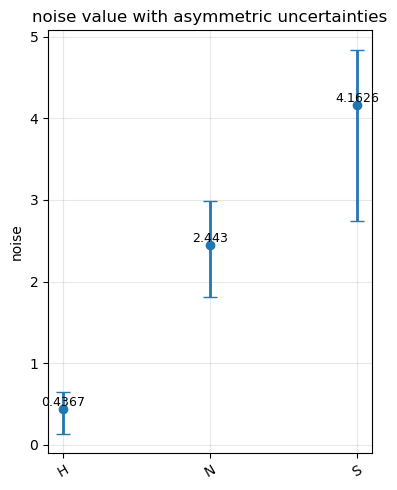

In [10]:
plot_fit_params.plot_param(H_line, N_line, S_line, labels=labels,
                                decimals=4)
